In [1]:
import os
import sys

import numpy as np
import pandas as pd
import polars as pl

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [25]:
from morai import models
from morai.experience import charters, tables
from morai.forecast import graduation, metrics, preprocessors
from morai.integrations import hmd
from morai.utils import custom_logger, helpers, sql

In [3]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

# Population Omega

Using the [human mortality database](https://www.mortality.org/Country/Country?cntr=USA) mortality rates, calculating the GLM omega rates

The data does include female, male, total qx from 1933 - 2023

A simple logistic regression will not fit the curve perfectly as there can be non-linear relationships with the shape of the curve. A spline is a good method to be able to model non-linear relationship as the mortality rates generally tend to accelerate and decelerate at different ages. It is recommended to use 3 degrees to represent gradual changes and somewhere between 3-5 knots.

In [1]:
from morai.models import r

## Data

In [4]:
db_filepath = r"files/integrations/hmd/hmd.sql"

In [5]:
hmd_usa_df = hmd.get_hmd_data_sql(db_filepath=db_filepath, table_name="hmd")

In [6]:
hmd_usa_df = hmd_usa_df[(hmd_usa_df["year"] >= 1950) & (hmd_usa_df["year"] <= 2023)]
hmd_usa_df["qx_raw"] = hmd_usa_df["total_death"] / hmd_usa_df["total_exposure"]

In [7]:
preprocess_dict = preprocessors.preprocess_data(
    hmd_usa_df,
    feature_dict={
        "target": ["qx_raw"],
        "weight": [],
        "passthrough": [
            "year",
            "age",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

 2025-11-27 13:17:04 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2025-11-27 13:17:04 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 13:17:04 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'year', 'constant'] 


## Models

### GLM

In [8]:
GLM = models.core.GLM()
GLM.fit(X, y)

 2025-11-27 13:17:04 | morai.models.core | INFO     | fiting the model 
 2025-11-27 13:17:04 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x0000025D675D75C0> family... 


In [10]:
hmd_usa_df["glm"] = GLM.predict(X)

### GAM

In [11]:
GAMR = r.GAMR()
spline_dict = {
    "age": {"bs": "tp"},
}

In [12]:
GAMR.setup_model(X=X, y=y, weights=weights, spline_dict=spline_dict)

 2025-11-27 13:17:11 | morai.models.r | INFO     | setup GAM model with mgcv and `quasibinomial` distribution with `logit` link 
 2025-11-27 13:17:16 | morai.models.r | INFO     | formula: 
 2025-11-27 13:17:16 | morai.models.r | INFO     | > qx_raw ~ s(`age`, bs='tp')+`constant`+`year` 
 2025-11-27 13:17:17 | morai.models.r | INFO     | fitting the model: 
 2025-11-27 13:17:17 | morai.models.r | INFO     | > model <- bam(formula, data=data, weights=weights, family=family, drop.intercept=TRUE)` 
 2025-11-27 13:17:18 | morai.models.r | INFO     | model fitted 


In [13]:
print(GAMR.summary(expand=True))

Generalized Additive Model (mgcv) Summary
Family                : quasibinomial
Link                  : logit
Number of Observations: 8214
Adjusted R-squared    : 0.931
Deviance Explained    : 96.3%
Scale Estimate        : 0.00808
fREML                 : -8090

Formula:
qx_raw ~ s(`age`, bs='tp')+`constant`+`year`

Parametric Coefficients:
constant   -12.288800
year         0.003983

Smooth Terms:
             edf    Ref.df            F  p-value     alpha
s(age)  8.941999  8.998176  9781.939908      0.0  0.000033

Expanded Smooth Terms:
        name       coef
2   s(age).1 -13.648854
3   s(age).2   4.235869
4   s(age).3   4.602604
5   s(age).4  -1.772755
6   s(age).5  -1.787473
7   s(age).6   2.045635
8   s(age).7  -1.718781
9   s(age).8  -1.255486
10  s(age).9  -6.055611


In [14]:
hmd_usa_df["gam"] = GAMR.predict(X)

 2025-11-27 13:17:18 | morai.models.r | INFO     | predicted rates 


## Compare

In [15]:
hmd_usa_df[hmd_usa_df["age"] >= 100]["total_death"].sum()

np.float64(924036.03)

In [16]:
hmd_usa_df[hmd_usa_df["age"] >= 100]["total_exposure"].sum()

np.float64(2091478.1400000001)

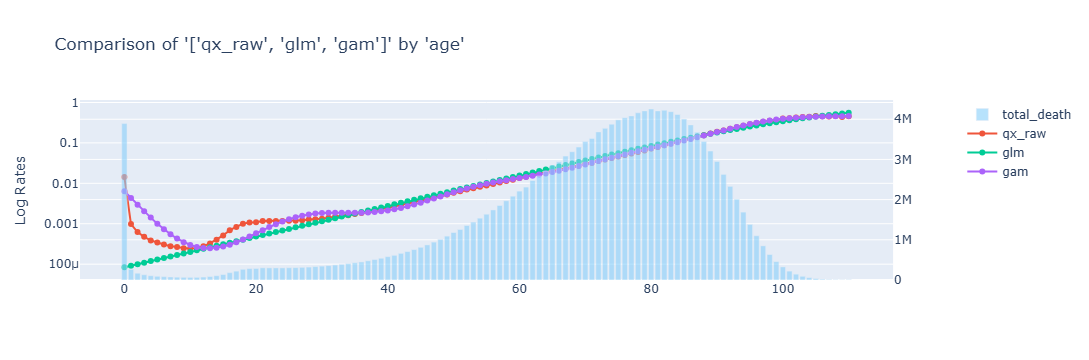

In [18]:
charters.compare_rates(
    df=hmd_usa_df,
    x_axis="age",
    rates=["qx_raw", "glm", "gam"],
    secondary="total_death",
    display=True,
    y_log=True,
)

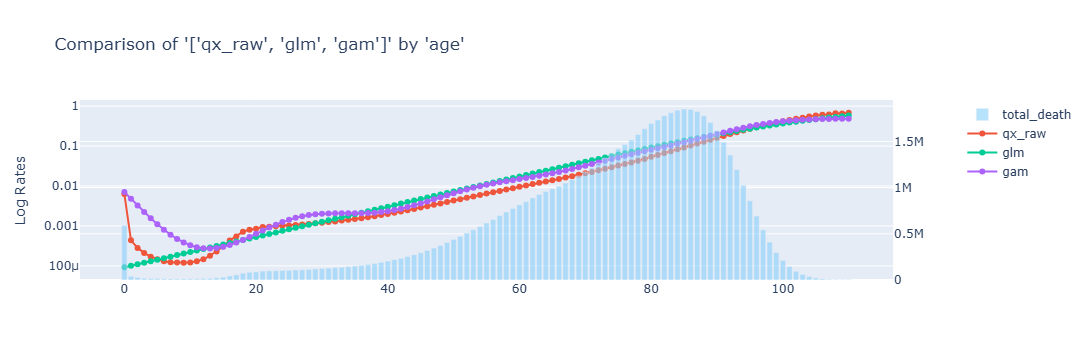

In [19]:
charters.compare_rates(
    df=hmd_usa_df[hmd_usa_df["year"] >= 2000],
    x_axis="age",
    rates=["qx_raw", "glm", "gam"],
    secondary="total_death",
    display=True,
    y_log=True,
)

# Mortality Improvement

## CDC 1D (year) - Raw Mortality Improvement Rates

The following looks raw mortality improvement rates and getting averages and smoothing.

CDC allows for querying the WONDER database to get deaths / exposures by year. Using this information a mortality rate can be calculated and then an mortality improvement rate can be calculated using the q(x) / q(x-1). To ensure the mortality rates are not influenced by exposure differences, the mortality improvement is standardized using the 2000 population.

In [14]:
from morai.integrations import cdc

In [86]:
db_filepath = helpers.FILES_PATH / "integrations" / "cdc" / "cdc.sql"

In [165]:
# get data
mcd79_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd79_mi")
mcd99_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd99_mi")
mcd18_mi = cdc.get_cdc_data_sql(db_filepath=db_filepath, table_name="mcd18_mi")
mcd18_mi = mcd18_mi[mcd18_mi["year"] >= 2021]
mi = pd.concat([mcd79_mi, mcd99_mi, mcd18_mi], axis=0, ignore_index=True)

In [166]:
# format age_group column
mi = cdc.map_reference(
    df=mi,
    col="value",
    on_dict={"age_groups": "key"},
    sheet_name="mapping",
    category="bin_age",
)
mi = mi.drop("age_groups", axis=1)
mi = mi.rename(columns={"value": "age_groups"})

In [167]:
mi_grouped = (
    mi.groupby(["year", "age_groups"])[["deaths", "population"]].sum().reset_index()
)
mi_grouped = cdc.map_reference(
    df=mi_grouped,
    col="population_%",
    on_dict={"age_groups": "age_bucket"},
    sheet_name="age_std_2000",
)

In [168]:
# filters and chart
# mi = mi[mi["age_groups"]=="85+ years"]
mi_no_covid = mi[(mi["year"] < 2020) | ((mi["year"] >= 2024) & (mi["year"] < 2019))]
mi_no_covid = cdc.calc_mi(df=mi_no_covid, rolling=10)

 2026-05-08 07:24:46 | morai.integrations.cdc | INFO     | calculating mortality improvement by using a `2000 age adjusted` crude mortality rate 


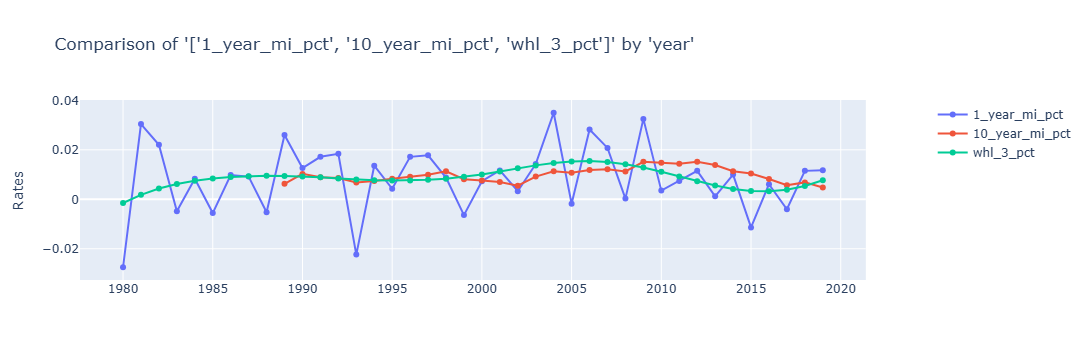

In [169]:
charters.compare_rates(
    df=mi_no_covid[mi_no_covid["age_groups"] == "All ages"],
    x_axis="year",
    rates=["1_year_mi_pct", "10_year_mi_pct", "whl_3_pct"],
)

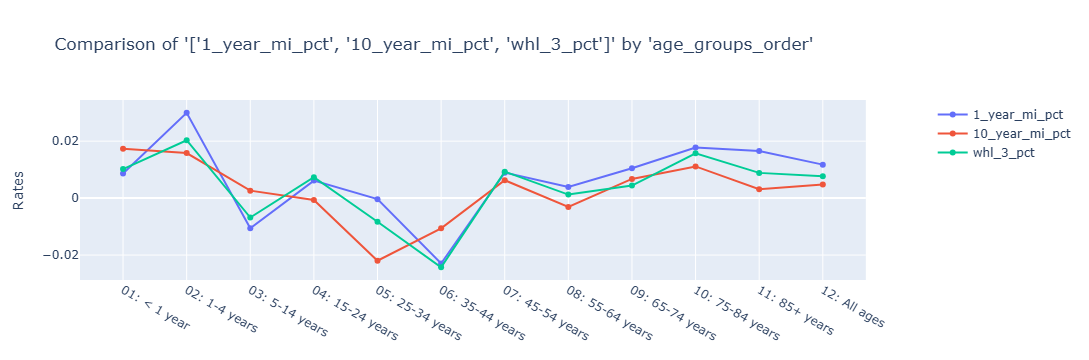

In [171]:
age_cats = mi_no_covid["age_groups"].cat.remove_unused_categories()
mi_no_covid["age_groups_order"] = age_cats.map(
    {cat: f"{i + 1:02d}: {cat}" for i, cat in enumerate(age_cats.cat.categories)}
).fillna(mi_no_covid["age_groups"].astype(str))
charters.compare_rates(
    df=mi_no_covid[mi_no_covid["year"] == 2019],
    x_axis="age_groups_order",
    rates=["1_year_mi_pct", "10_year_mi_pct", "whl_3_pct"],
)

## SSA 2D (age/year) - Raw Mortality Rates

The SSA provides mortality rates that can used to create a 2d mortality rate table. From this 2d table mortality improvement rates can be derived. The mortality rates are transformed for smoothing.

- SSA downloads: https://www.ssa.gov/OACT/Downloadables/CY/index.html
- year order and lamda: 3, 100
- age order and lamda: 3, 400

In [193]:
ssa_females = r"notebooks/files/DeathProbsE_F_Hist_TR2021.csv"

In [194]:
# raw mortality
df = pd.read_csv(ssa_females, skiprows=1, index_col=0)
df.columns = df.columns.astype(int)
df = df.loc[1950:2019, 15:97]
df_log = np.log(df)

# smoothed mortality
grad = graduation.whl(
    rates=df_log,
    horizontal_order=3,
    horizontal_lambda=400,
    vertical_order=3,
    vertical_lambda=100,
    normalize_weights=True,
)
df_exp = np.exp(pd.DataFrame(grad, index=df.index, columns=df.columns.astype(int)))

In [195]:
df_exp.loc[1982:2019, :]

,15,16,17,18,19,20,21,22,23,24,...,88,89,90,91,92,93,94,95,96,97
Year,,,,,,,,,,,,,,,,,,,,,
1982,0.000412,0.000446,0.000477,0.000505,0.000529,0.000549,0.000565,0.000578,0.000590,0.000600,...,0.119341,0.130906,0.143240,0.156325,0.170139,0.184648,0.199814,0.215589,0.231922,0.248751
1983,0.000408,0.000440,0.000470,0.000497,0.000519,0.000539,0.000555,0.000568,0.000580,0.000591,...,0.118634,0.130204,0.142562,0.155692,0.169571,0.184166,0.199440,0.215347,0.231832,0.248838
1984,0.000406,0.000437,0.000465,0.000491,0.000513,0.000531,0.000547,0.000560,0.000572,0.000584,...,0.118065,0.129663,0.142072,0.155280,0.169261,0.183986,0.199415,0.215501,0.232193,0.249430
1985,0.000406,0.000436,0.000463,0.000487,0.000508,0.000525,0.000541,0.000554,0.000567,0.000580,...,0.117531,0.129167,0.141644,0.154947,0.169055,0.183936,0.199549,0.215849,0.232781,0.250288
1986,0.000408,0.000436,0.000462,0.000485,0.000504,0.000521,0.000536,0.000550,0.000563,0.000577,...,0.116944,0.128616,0.141158,0.154559,0.168796,0.183836,0.199640,0.216159,0.233341,0.251126
1987,0.000411,0.000437,0.000461,0.000483,0.000502,0.000518,0.000533,0.000546,0.000560,0.000575,...,0.116254,0.127949,0.140543,0.154025,0.168374,0.183557,0.199533,0.216254,0.233665,0.251708
1988,0.000412,0.000437,0.000460,0.000481,0.000499,0.000514,0.000529,0.000543,0.000557,0.000573,...,0.115466,0.127165,0.139788,0.153325,0.167757,0.183050,0.199162,0.216045,0.233645,0.251905
1989,0.000413,0.000437,0.000458,0.000478,0.000495,0.000510,0.000525,0.000539,0.000554,0.000571,...,0.114639,0.126327,0.138956,0.152521,0.167001,0.182365,0.198571,0.215570,0.233309,0.251731
1990,0.000412,0.000435,0.000455,0.000474,0.000490,0.000505,0.000520,0.000534,0.000549,0.000567,...,0.113892,0.125562,0.138187,0.151762,0.166268,0.181674,0.197939,0.215015,0.232850,0.251388


# Reload

In [157]:
import importlib

importlib.reload(cdc)

<module 'morai.integrations.cdc' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\integrations\\cdc.py'>